# Seasonal Agriculture Performance Analysis

**Major Project - VOIS AICTE Batch 1 2026-2027**

This notebook analyzes seasonal agricultural performance data to identify patterns, trends and relationships across Kharif, Rabi and Zaid seasons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
#Loading the dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

## 1. Exploring the Dataset

In [3]:
#review top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.tail() #Last five rows.

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
#Number of columns and rows
df.shape

(4000, 28)

In [6]:
#column names
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [7]:
#data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [8]:
#stastical info
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


## 2. Data Cleaning and Preparation

In [9]:
#data quality check
duplicate_count = df.duplicated().sum()
print('Duplicate Rows', duplicate_count)

Duplicate Rows 0


In [10]:
df = df.drop_duplicates().copy()
print('Duplicates remaining', df.duplicated().sum())

Duplicates remaining 0


In [11]:
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})

missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [12]:
# Rainfall, soil moisture and yield have missing values.
# Since farming conditions differ a lot by season, filling with the
# season-wise median is more realistic than a single overall median.
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

In [13]:
missing_after = df.isna().sum()
missing_after[missing_after > 0]  # should be empty now

Series([], dtype: int64)

In [14]:
# Basic sanity check on value ranges (looking for impossible values)
df[['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
    'Humidity_pct', 'Soil_pH', 'Yield_Tonnes_Ha']].describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_pH,Yield_Tonnes_Ha
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000
mean,7.888265,600.714313,26.81890,63.210500,6.701010,5.241955
std,4.223764,288.427366,3.81818,11.960834,0.641461,13.311661
min,0.500000,80.000000,16.20000,25.000000,5.200000,0.300000
25%,4.260000,370.425000,23.90000,54.775000,6.260000,1.050000
50%,7.895000,581.000000,26.90000,63.000000,6.690000,1.730000
75%,11.650000,836.125000,29.60000,71.900000,7.140000,2.830000
max,15.000000,1395.200000,39.70000,95.000000,8.400000,101.440000


In [15]:
#Feature engineering: cost per hectare and profit margin help compare farms of different sizes fairly
df['Cost_per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df[['Cost_per_Hectare', 'Profit_Margin_pct']].describe()

,Cost_per_Hectare,Profit_Margin_pct
count,4000.000000,4000.000000
mean,66660.084938,-45.492178
std,8845.644258,158.085472
min,35807.382550,-1461.851219
25%,60597.205943,-60.192762
50%,66614.048166,1.146236
75%,72739.977527,32.885876
max,97185.351090,85.921220


## 3. Seasonal Distribution

In [16]:
season_counts = df['Season'].value_counts()
season_counts

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

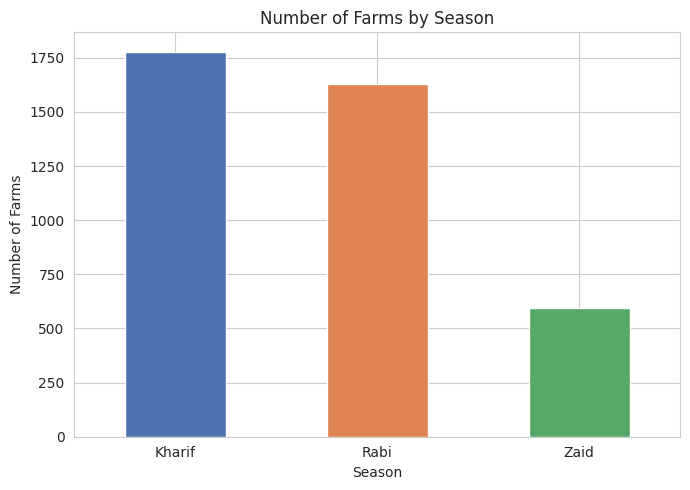

In [17]:
# Chart 1: Number of farms recorded per season
plt.figure(figsize=(7, 5))
season_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
crop_season = pd.crosstab(df['Crop'], df['Season'])
crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


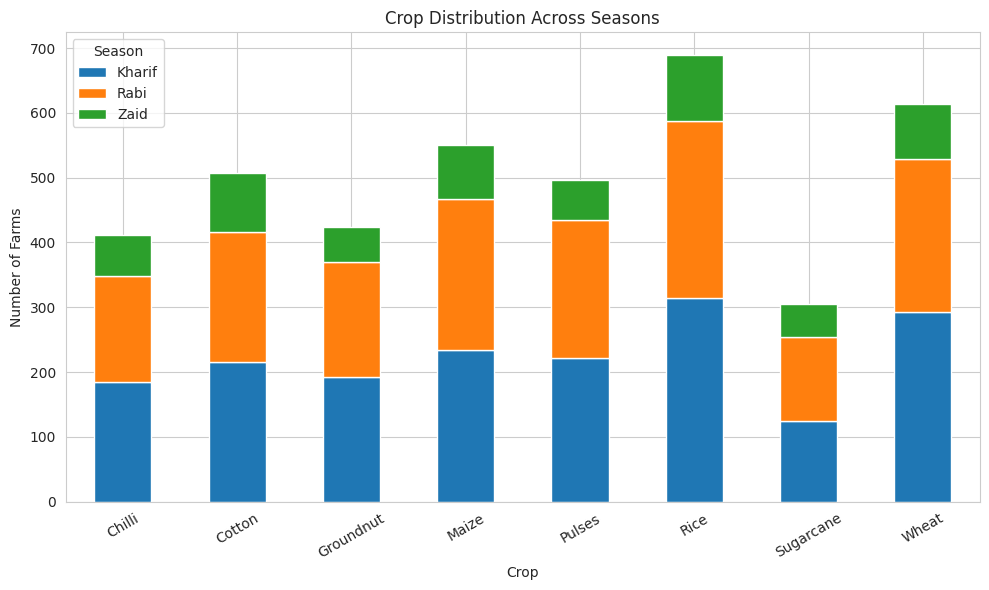

In [19]:
# Chart 2: Crop distribution across seasons
crop_season.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Crop Distribution Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Seasonal Environmental Conditions

In [20]:
env_by_season = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C',
                                          'Humidity_pct', 'Sunlight_Hours_Day',
                                          'Soil_Moisture_pct']].mean().round(2)
env_by_season

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.11,28.45,71.81,6.79,31.20
Rabi,435.94,23.49,57.89,7.59,24.05
Zaid,299.12,31.04,52.01,8.18,19.17


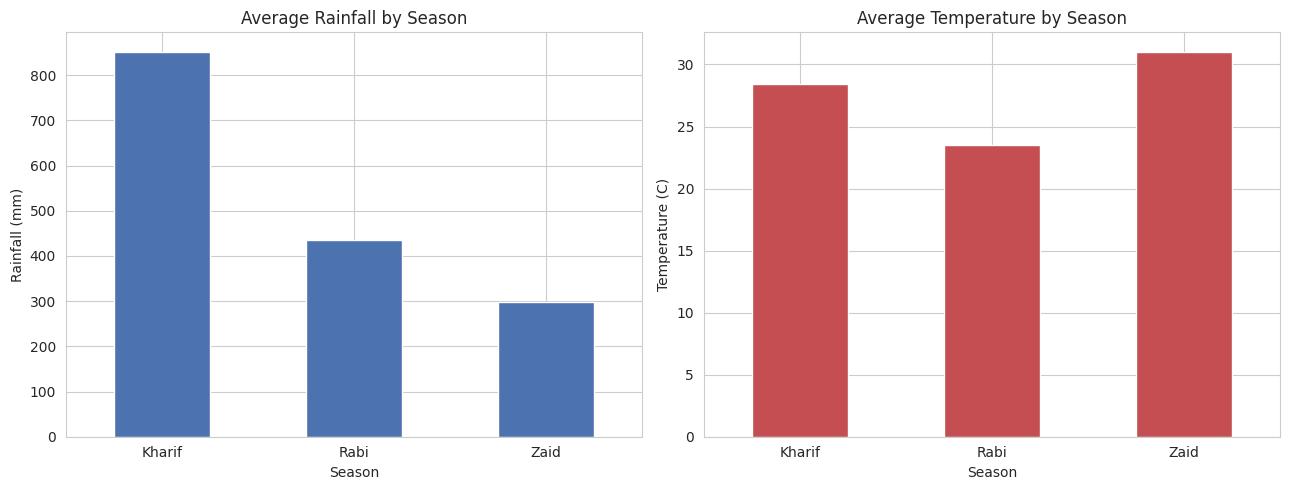

In [21]:
# Chart 3: Average rainfall and temperature by season
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

env_by_season['Rainfall_mm'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Average Rainfall by Season')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].set_xlabel('Season')
axes[0].tick_params(axis='x', rotation=0)

env_by_season['Avg_Temperature_C'].plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Average Temperature by Season')
axes[1].set_ylabel('Temperature (C)')
axes[1].set_xlabel('Season')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

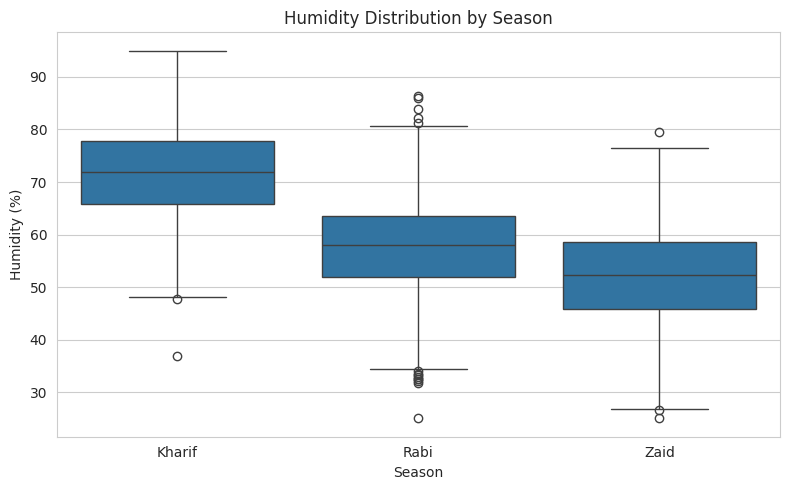

In [22]:
# Chart 4: Humidity distribution by season
plt.figure(figsize=(8, 5))
sns.boxplot(x='Season', y='Humidity_pct', data=df)
plt.title('Humidity Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

## 5. Yield and Production Performance

In [23]:
yield_by_season = df.groupby('Season')['Yield_Tonnes_Ha'].agg(['mean', 'median', 'std']).round(2)
yield_by_season

,mean,median,std
Season,,,
Kharif,5.63,1.95,14.39
Rabi,5.04,1.66,12.75
Zaid,4.64,1.45,11.27


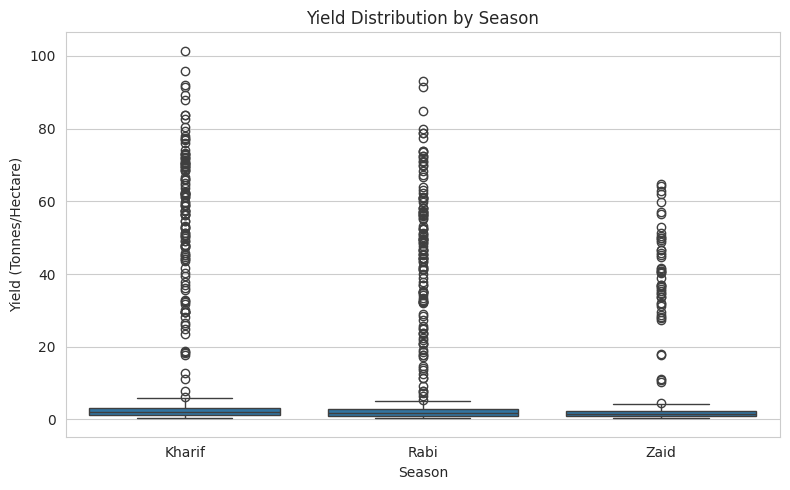

In [24]:
# Chart 5: Yield distribution by season
plt.figure(figsize=(8, 5))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df)
plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

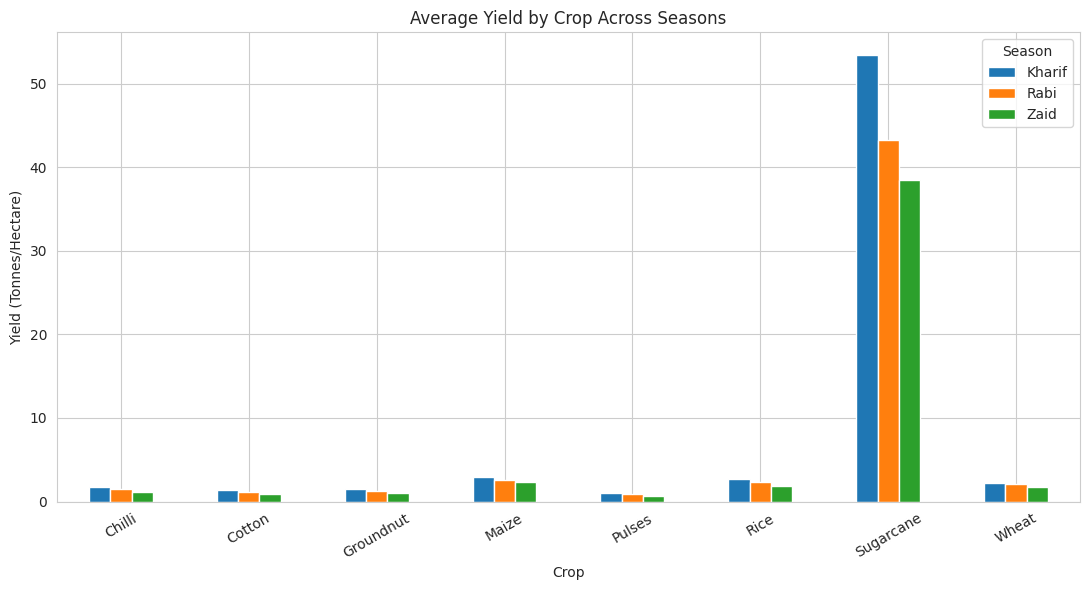

In [25]:
# Chart 6: Average yield by crop and season
crop_season_yield = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().unstack()
crop_season_yield.plot(kind='bar', figsize=(11, 6))
plt.title('Average Yield by Crop Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Resource Usage Across Seasons

In [26]:
resource_by_season = df.groupby('Season')[['Fertilizer_kg_ha', 'Pesticide_Litre_ha',
                                              'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']].mean().round(2)
resource_by_season

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


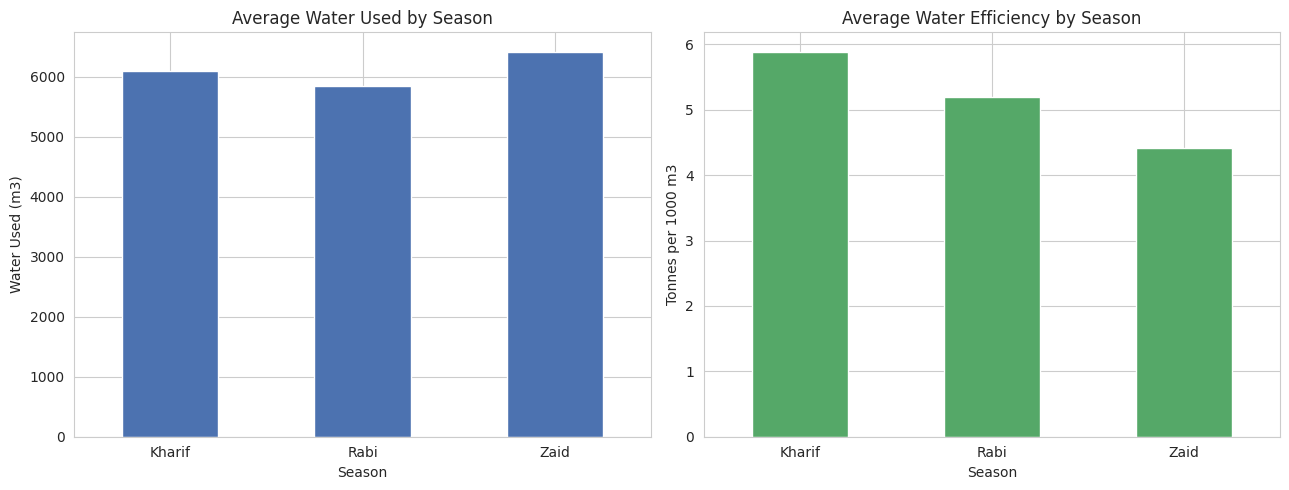

In [27]:
# Chart 7: Water used vs water efficiency by season
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

resource_by_season['Water_Used_m3'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Average Water Used by Season')
axes[0].set_ylabel('Water Used (m3)')
axes[0].tick_params(axis='x', rotation=0)

resource_by_season['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Average Water Efficiency by Season')
axes[1].set_ylabel('Tonnes per 1000 m3')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

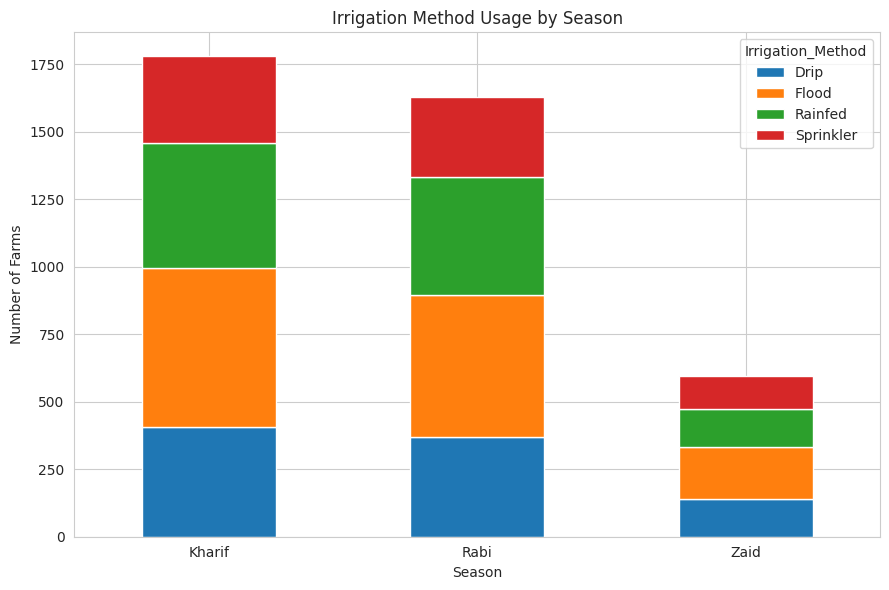

In [28]:
# Chart 8: Irrigation method usage across seasons
irrigation_season = pd.crosstab(df['Season'], df['Irrigation_Method'])
irrigation_season.plot(kind='bar', stacked=True, figsize=(9, 6))
plt.title('Irrigation Method Usage by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Economic Performance Across Seasons

In [29]:
economics_by_season = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR',
                                               'Profit_INR', 'Profit_Margin_pct']].mean().round(2)
economics_by_season

,Total_Cost_INR,Revenue_INR,Profit_INR,Profit_Margin_pct
Season,,,,
Kharif,531804.41,710719.06,178914.65,-38.64
Rabi,513836.58,601526.05,87689.47,-44.27
Zaid,543976.73,519171.90,-24804.82,-69.35


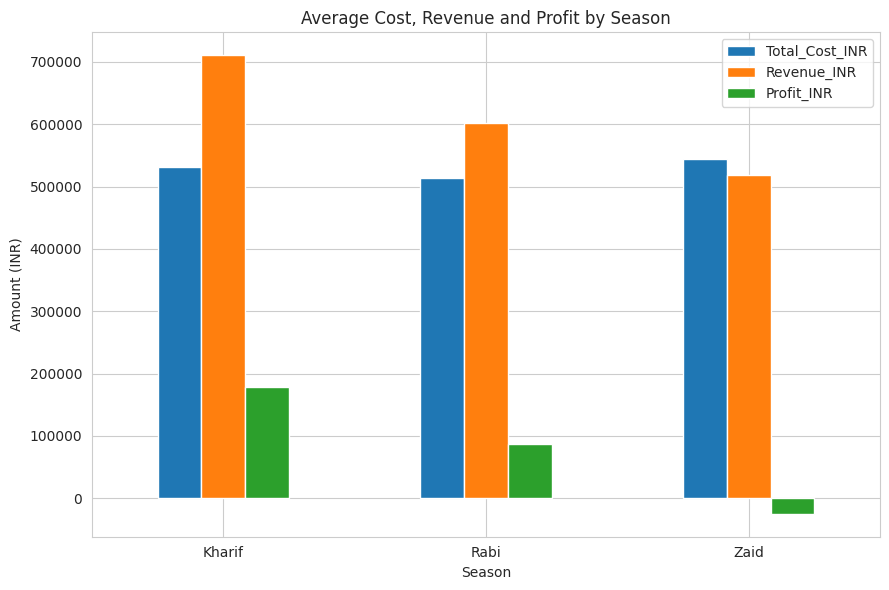

In [30]:
# Chart 9: Average cost, revenue and profit by season
economics_by_season[['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].plot(kind='bar', figsize=(9, 6))
plt.title('Average Cost, Revenue and Profit by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
# Loss-making farms: how common are they, and does it vary by season?
loss_by_season = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean() * 100).round(1)
loss_by_season.name = 'Loss_Making_Farms_pct'
loss_by_season

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Loss_Making_Farms_pct, dtype: float64

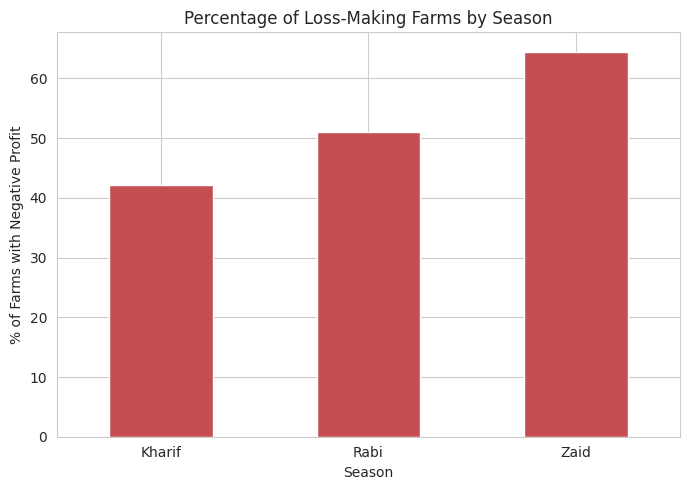

In [32]:
# Chart 10: Percentage of loss-making farms by season
plt.figure(figsize=(7, 5))
loss_by_season.plot(kind='bar', color='#C44E52')
plt.title('Percentage of Loss-Making Farms by Season')
plt.xlabel('Season')
plt.ylabel('% of Farms with Negative Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Relationships Between Environmental Conditions and Performance

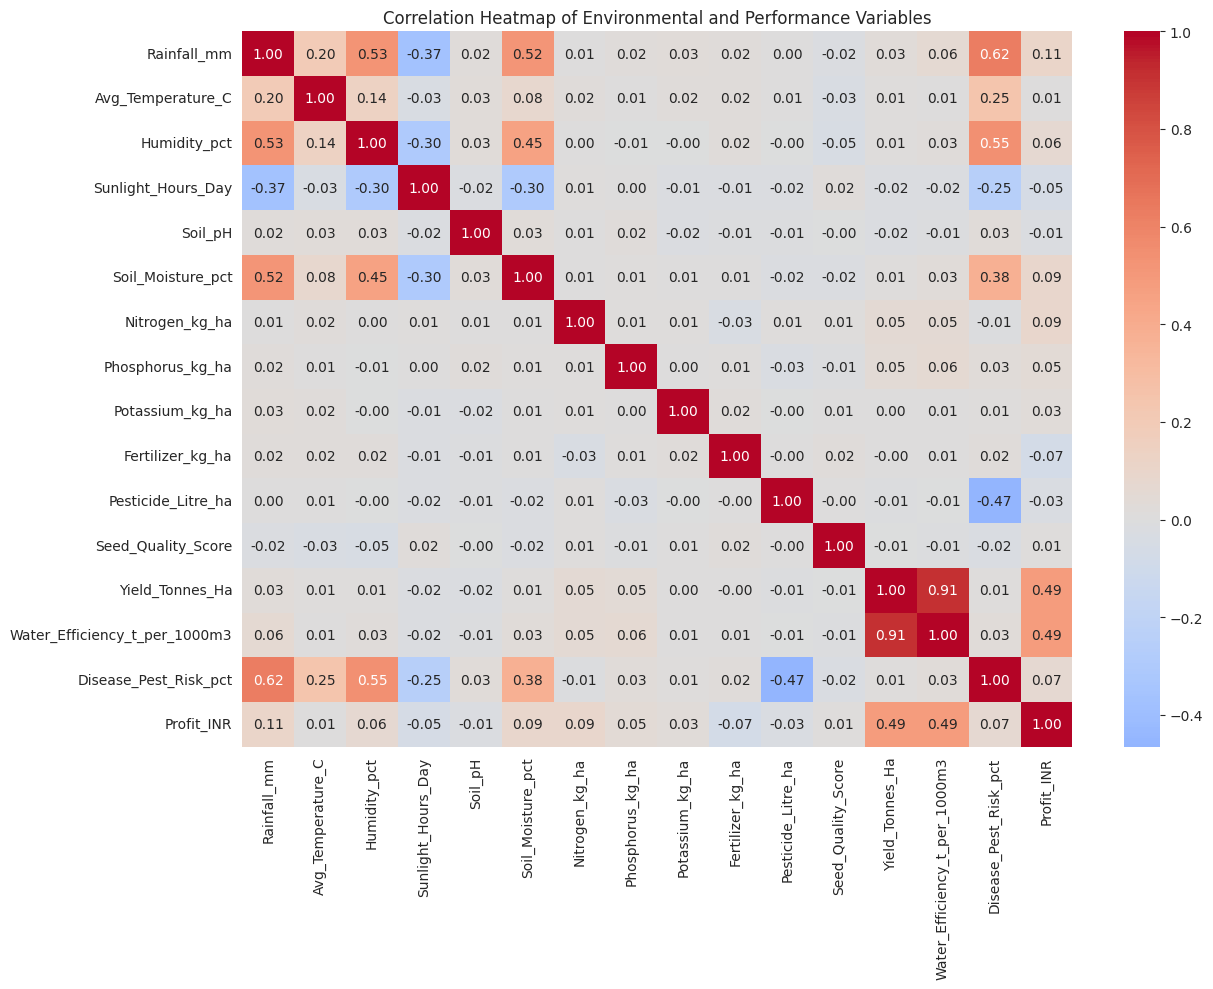

In [33]:
numeric_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
                 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
                 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
                 'Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct',
                 'Profit_INR']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Environmental and Performance Variables')
plt.tight_layout()
plt.show()

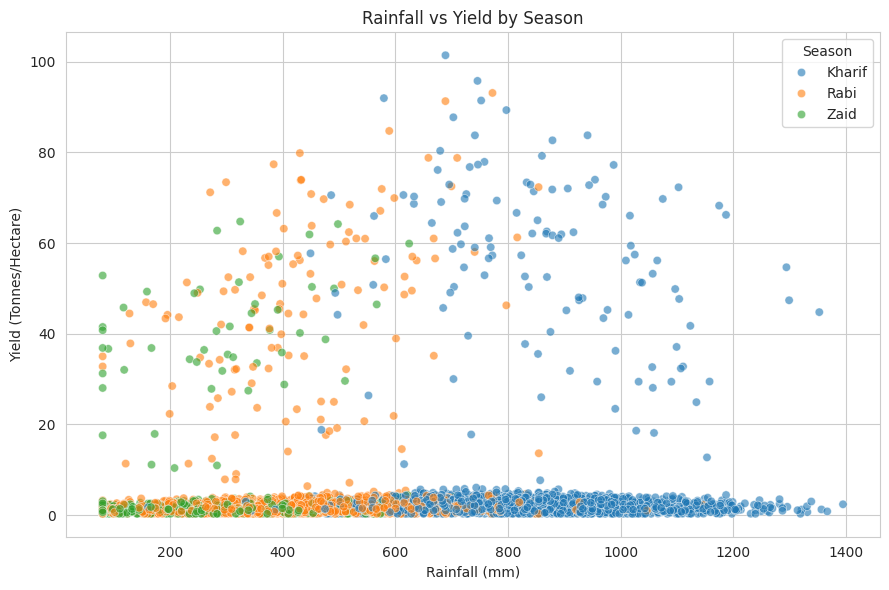

In [34]:
# Chart 11: Rainfall vs Yield, colored by season
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', data=df, alpha=0.6)
plt.title('Rainfall vs Yield by Season')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

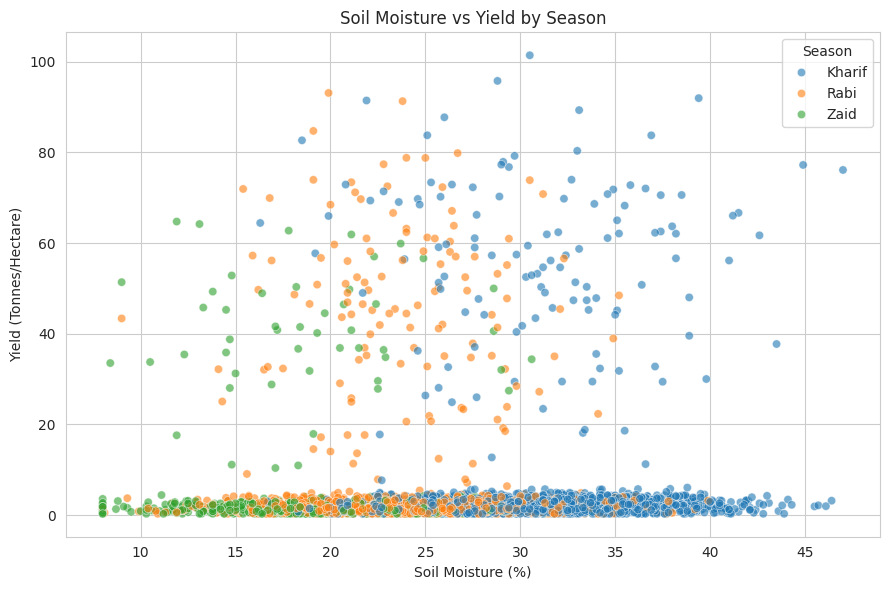

In [35]:
# Chart 12: Soil moisture vs Yield, colored by season
plt.figure(figsize=(9, 6))
sns.scatterplot(x='Soil_Moisture_pct', y='Yield_Tonnes_Ha', hue='Season', data=df, alpha=0.6)
plt.title('Soil Moisture vs Yield by Season')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.tight_layout()
plt.show()

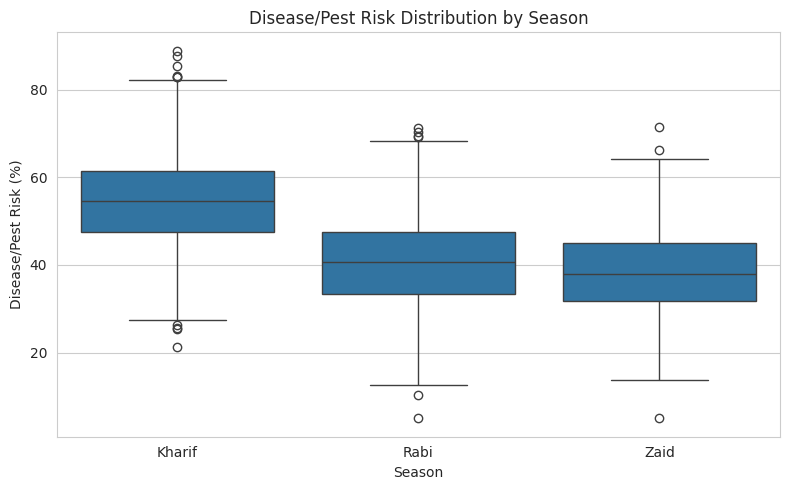

In [36]:
# Chart 13: Disease/Pest risk by season
plt.figure(figsize=(8, 5))
sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df)
plt.title('Disease/Pest Risk Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()

## 9. State-wise Seasonal Comparison

In [37]:
state_season_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.44,4.06
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.47
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


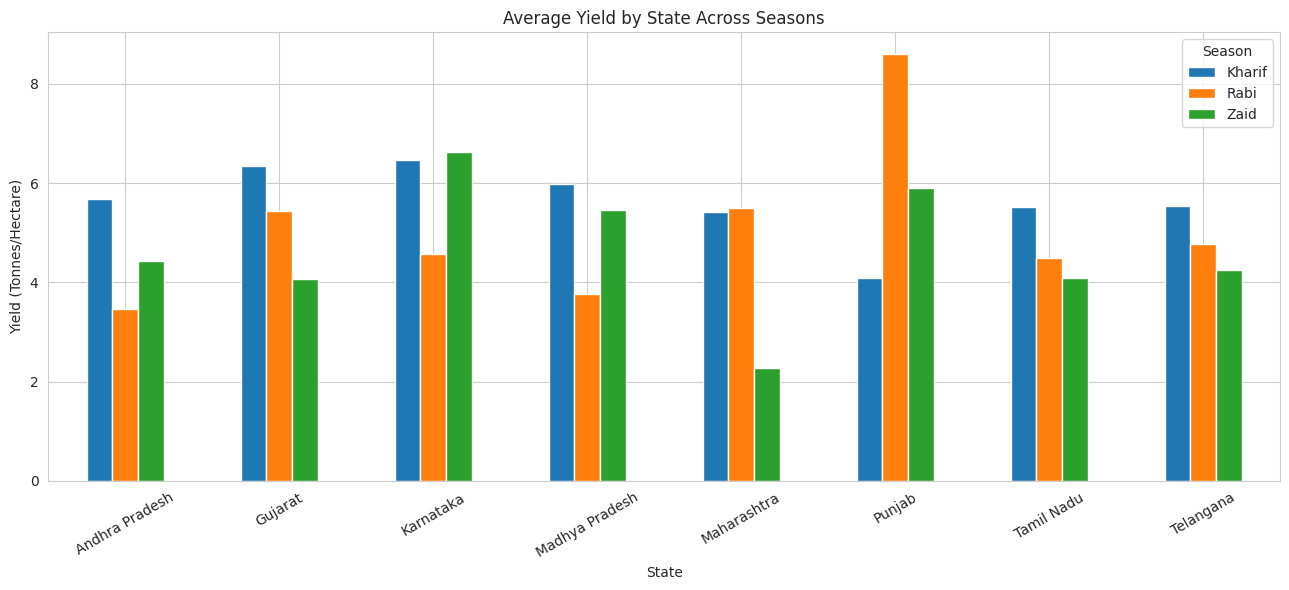

In [38]:
# Chart 14: Average yield by state across seasons
state_season_yield.plot(kind='bar', figsize=(13, 6))
plt.title('Average Yield by State Across Seasons')
plt.xlabel('State')
plt.ylabel('Yield (Tonnes/Hectare)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 10. Combined Seasonal Dashboard

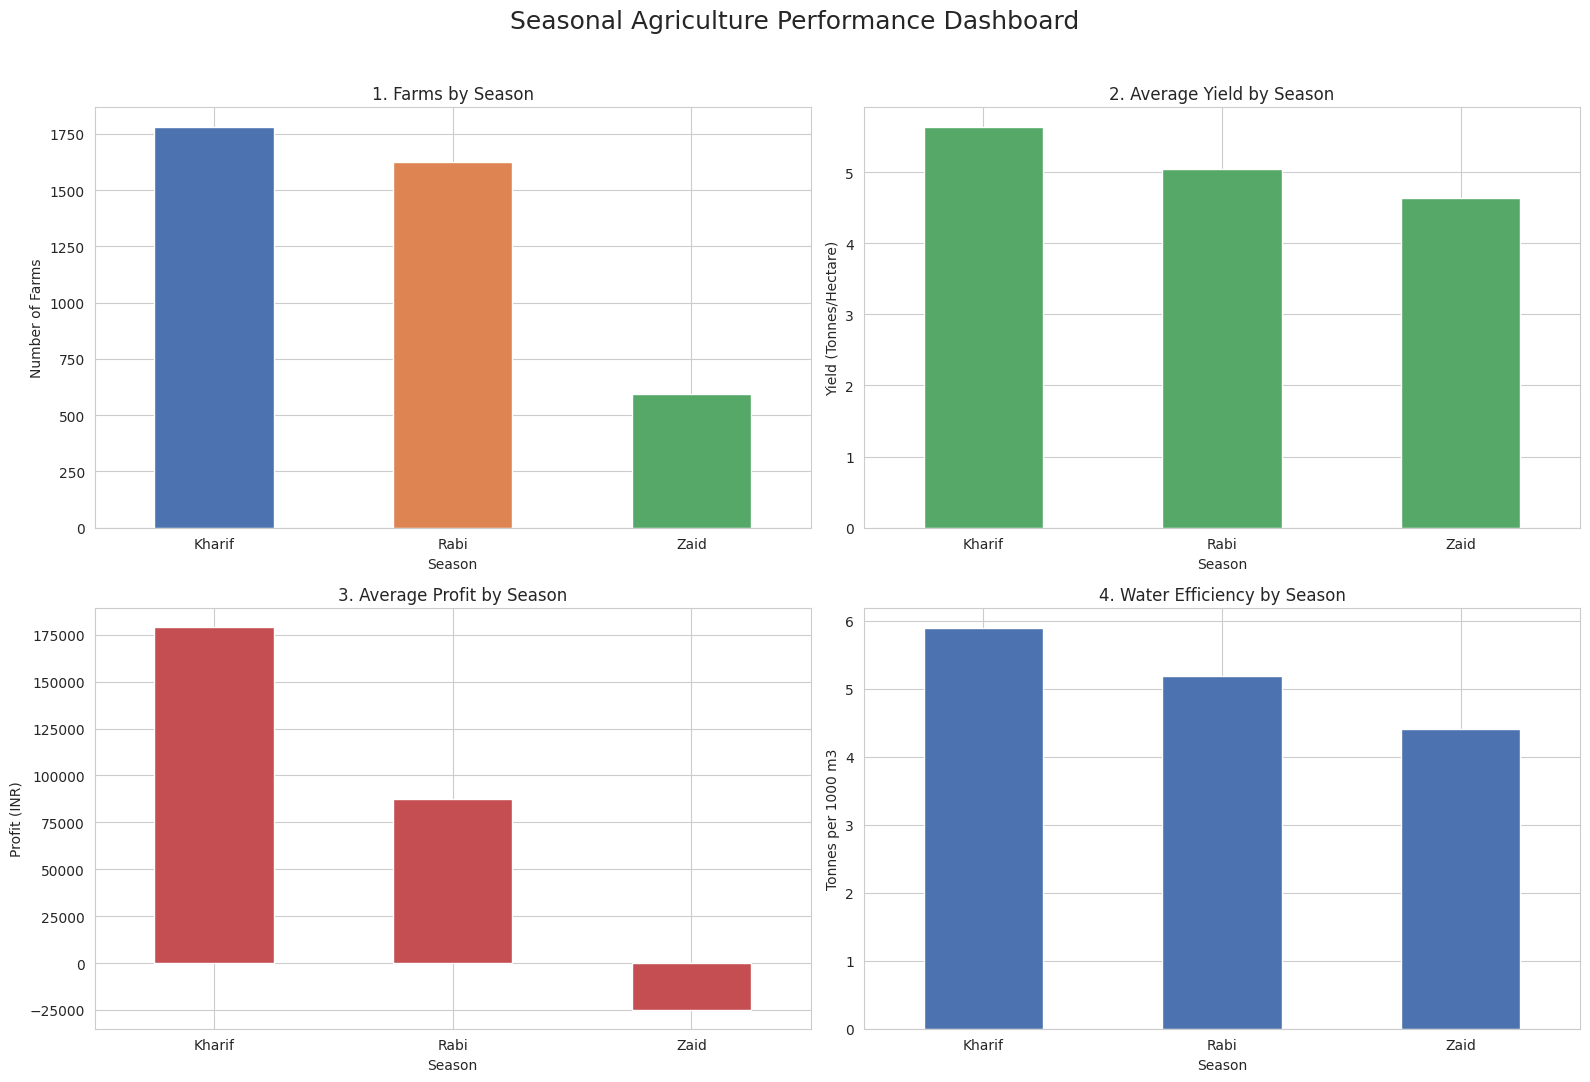

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Seasonal Agriculture Performance Dashboard', fontsize=18)

season_counts.plot(kind='bar', ax=axes[0, 0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0, 0].set_title('1. Farms by Season')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Number of Farms')
axes[0, 0].tick_params(axis='x', rotation=0)

yield_by_season['mean'].plot(kind='bar', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('2. Average Yield by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Yield (Tonnes/Hectare)')
axes[0, 1].tick_params(axis='x', rotation=0)

economics_by_season['Profit_INR'].plot(kind='bar', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('3. Average Profit by Season')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('Profit (INR)')
axes[1, 0].tick_params(axis='x', rotation=0)

resource_by_season['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[1, 1], color='#4C72B0')
axes[1, 1].set_title('4. Water Efficiency by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Tonnes per 1000 m3')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 11. Key Findings

- **Kharif** season has the highest number of farms recorded, followed by **Rabi** and then **Zaid**, which is the smallest and shortest season.
- Average **rainfall** is clearly highest in Kharif (monsoon-driven) and lowest in Zaid, while Zaid shows higher average temperature, consistent with real-world seasonal patterns.
- **Yield** is generally higher in Kharif compared to Rabi and Zaid, though the spread (variation) within each season is wide, showing that season alone does not guarantee good yield.
- **Water efficiency** (tonnes produced per 1000 m3 of water) tends to be lower in seasons with heavier irrigation dependence, suggesting irrigation method matters as much as season.
- A large proportion of farms across all seasons show **negative profit**, indicating that cost of cultivation (fertilizer, pesticide, water, seeds) frequently exceeds revenue at current market prices — this is a pattern worth flagging for stakeholders regardless of season.
- The correlation heatmap shows **yield has a positive relationship with soil moisture and rainfall**, and a negative relationship with disease/pest risk, while profit is most strongly tied to yield and market price rather than any single environmental factor.
- Crop-wise yield varies by season for the same crop (e.g., Rice performs differently across Kharif/Rabi/Zaid), showing that season-crop combination affects performance more than crop type alone.
- State-wise yield patterns are not identical — some states maintain relatively consistent yield across seasons while others show sharp seasonal swings, pointing to regional agro-climatic differences.

## 12. Recommendations

1. **Season-specific irrigation planning**: Since Zaid shows lower water efficiency, promoting drip/sprinkler irrigation in that season could improve output per unit of water.
2. **Cost control focus**: Given the high share of loss-making farms across all seasons, subsidies or bulk input procurement support for fertilizer/pesticide could improve farmer margins more effectively than season-specific interventions alone.
3. **Crop-season matching**: Encourage crops that historically show higher yield in a given season and region combination (from the crop-season-state analysis) rather than uniform cropping patterns.
4. **Disease/pest monitoring**: Since disease/pest risk correlates negatively with yield, targeted pest advisories timed to the seasons with higher observed risk could reduce losses.
5. **Further investigation**: State-level and crop-level deep dives (beyond this seasonal-level analysis) would help pinpoint which specific state-crop-season combinations are underperforming and need the most support.
